# Delivery Bottleneck Hubs - Day 18
**Evan William | PySpark 4.0.1 | dataset simulasi, bukan data operasional nyata.**

Pertanyaan: hub mana yang membuat paket menunggu paling lama, setelah scan yang
tidak lengkap atau tidak sah dikeluarkan? Notebook menghasilkan audit kualitas,
dwell setiap package x hub, rata-rata, median, dan lima hub teratas.

Output tersimpan sudah dieksekusi dengan Spark lokal. Untuk menjalankan di Colab,
unggah `scan_events.csv`, `generate_dataset.py`, `prepare_runtime.py`, dan `spark_analysis.py` lewat panel Files,
lalu pilih **Runtime > Run all**. Jika CSV tidak diunggah, generator membuat dataset
identik secara deterministik. Seluruh transformasi utama memakai Spark, bukan Pandas.

## 5 Vs dan batas Pandas

| V | Makna pada log pengiriman |
|---|---|
| Volume | Jutaan paket x beberapa hub x dua atau lebih scan; dataset latihan ini kecil. |
| Velocity | Scan masuk terus-menerus; analisis batch ini belum streaming. |
| Variety | CSV scan, JSON aplikasi, GPS; latihan hanya empat kolom CSV. |
| Veracity | Scan duplikat, hilang, jam salah, dan event tidak dikenal harus diaudit. |
| Value | Prioritaskan investigasi hub berdasarkan waktu tunggu dan bukti yang cukup. |

Pandas biasa bekerja pada RAM satu mesin. Data, join, dan intermediate yang lebih
besar daripada RAM dapat gagal; chunking membantu tetapi tidak otomatis memberi
distribusi join/grouping atau toleransi kegagalan. Spark membagi pekerjaan ke
partisi, memakai lazy evaluation dan dapat berjalan pada cluster. `local[2]` di sini
membuktikan mesin Spark berjalan, **bukan** benchmark data raksasa atau cluster.
Exact median memberi hasil tepat pada latihan; pada skala besar pertimbangkan
`percentile_approx` dengan akurasi yang dinyatakan, partisi, dan Spark UI.

In [1]:
import importlib.util
import subprocess
import sys
import os
from pathlib import Path

if importlib.util.find_spec("pyspark") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyspark==4.0.1"])
base = Path.cwd()
if (base / "analysis/spark_analysis.py").exists():
    sys.path.insert(0, str(base / "analysis"))
elif (base / "spark_analysis.py").exists():
    sys.path.insert(0, str(base))  # Colab Files upload
else:
    raise FileNotFoundError("Upload spark_analysis.py dan generate_dataset.py ke Colab Files.")
from generate_dataset import generate, ROOT as generator_root
from spark_analysis import SCHEMA, quality_check, export_results
from prepare_runtime import prepare_runtime
prepare_runtime()
dataset = base / "data/scan_events.csv"
if not dataset.exists():
    dataset = base / "scan_events.csv"
if not dataset.exists():
    generate()
    dataset = generator_root / "data/scan_events.csv"

from pyspark.sql import SparkSession, functions as F
import csv
with dataset.open(encoding="utf-8", newline="") as f:
    assert next(csv.reader(f)) == ["hub_id", "package_id", "event_type", "timestamp"], "CSV schema mismatch"
spark = (SparkSession.builder.master("local[2]").appName("delivery-bottleneck-hubs")
         .config("spark.sql.session.timeZone", "UTC")
         .config("spark.sql.shuffle.partitions", "4")
         .config("spark.driver.bindAddress", "127.0.0.1")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version, "| master:", spark.sparkContext.master)
raw = spark.read.option("header", True).schema(SCHEMA).csv(str(dataset))
raw.printSchema()
raw.show(8, truncate=False)

Spark version: 4.0.1 | master: local[2]


root
 |-- hub_id: string (nullable = true)
 |-- package_id: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- timestamp: string (nullable = true)



+-------+----------+----------+--------------------+
|hub_id |package_id|event_type|timestamp           |
+-------+----------+----------+--------------------+
|HUB_JKT|PKG-00043 |ARRIVAL   |2026-09-18T09:43:00Z|
|HUB_MKS|PKG-00029 |ARRIVAL   |2026-09-15T11:29:00Z|
|HUB_MKS|PKG-00228 |ARRIVAL   |2026-09-11T11:48:00Z|
|HUB_MKS|PKG-00097 |DEPARTURE |2026-09-25T02:02:48Z|
|HUB_MED|PKG-00053 |ARRIVAL   |2026-09-18T01:53:00Z|
|HUB_JKT|PKG-00482 |DEPARTURE |2026-09-18T23:46:24Z|
|HUB_SMG|PKG-00209 |ARRIVAL   |2026-09-06T01:29:00Z|
|HUB_MKS|PKG-00244 |ARRIVAL   |2026-09-18T05:04:00Z|
+-------+----------+----------+--------------------+
only showing top 8 rows


## Audit kualitas sebelum perhitungan

Duplikat berarti keempat kolom sama persis; hapus salinan berlebih tetapi catat
jumlahnya per hub. Grup tanpa kunci dibuang terpisah. Timestamp rusak dan event
tidak dikenal tetap dipertahankan dalam audit grup agar tidak diam-diam menjadi
pasangan valid. Grup valid mempunyai tepat satu ARRIVAL dan satu DEPARTURE setelah
deduplikasi, keduanya timestamp sah, urutan benar, serta tidak ada event asing.

Kunjungan berulang dengan beberapa ARRIVAL/DEPARTURE ditolak sebagai ambigu;
`min` hanya mengambil timestamp setelah aturan tepat-satu dipenuhi. Dwell nol
sah. Flag masalah dapat tumpang tindih, sehingga jangan menjumlahkan flag sebagai
jumlah grup yang dibuang. Tidak ada batas dwell arbitrer yang membuang outlier.

In [2]:
import json
groups, quality, summary = quality_check(raw)
print(json.dumps(summary, indent=2))
quality.orderBy("hub_id").show(truncate=False)
groups.filter(~F.col("is_valid_pair")).select(
    "hub_id", "package_id", "arrival_count", "departure_count", "invalid_timestamp",
    "ambiguous_pair", "departure_before_arrival").show(12, truncate=False)
assert summary["valid_pairs"] + summary["excluded_pairs"] == summary["candidate_pairs"]
assert summary["raw_events"] - summary["deduplicated_events"] == summary["duplicate_extra_events"]

{
  "raw_events": 4598,
  "deduplicated_events": 4574,
  "duplicate_extra_events": 24,
  "missing_key_events": 2,
  "invalid_timestamp_events": 24,
  "candidate_pairs": 2318,
  "valid_pairs": 2182,
  "missing_arrival_pairs": 40,
  "missing_departure_pairs": 40,
  "invalid_timestamp_pairs": 24,
  "unknown_event_pairs": 8,
  "ambiguous_pair_pairs": 8,
  "departure_before_arrival_pairs": 16,
  "excluded_pairs": 136
}


+----------+---------------+-----------+---------------+-----------------+-----------------+-------------+--------------+------------------------+----------------------+------------------+
|hub_id    |candidate_pairs|valid_pairs|missing_arrival|missing_departure|invalid_timestamp|unknown_event|ambiguous_pair|departure_before_arrival|duplicate_extra_events|valid_pair_pct    |
+----------+---------------+-----------+---------------+-----------------+-----------------+-------------+--------------+------------------------+----------------------+------------------+
|HUB_BDG   |317            |300        |5              |5                |3                |1            |1             |2                       |3                     |94.6372239747634  |
|HUB_DPS   |217            |200        |5              |5                |3                |1            |1             |2                       |3                     |92.16589861751152 |
|HUB_JKT   |517            |500        |5              

+-------+----------+-------------+---------------+-----------------+--------------+------------------------+
|hub_id |package_id|arrival_count|departure_count|invalid_timestamp|ambiguous_pair|departure_before_arrival|
+-------+----------+-------------+---------------+-----------------+--------------+------------------------+
|HUB_BDG|UNKNOWN   |1            |1              |false            |false         |false                   |
|HUB_DPS|AMBIGUOUS |2            |1              |false            |true          |false                   |
|HUB_JKT|REVERSE-0 |1            |1              |false            |false         |true                    |
|HUB_SBY|MISS-D-1  |1            |0              |false            |false         |false                   |
|HUB_BDG|REVERSE-1 |1            |1              |false            |false         |true                    |
|HUB_MKS|REVERSE-0 |1            |1              |false            |false         |true                    |
|HUB_SBY|MISS-D-4  

## Dwell dan agregasi

`(unix_timestamp(departure_at) - unix_timestamp(arrival_at)) / 3600` menghasilkan
jam, bukan hari atau menit. Pengelompokan menggunakan **kedua kunci**, bukan hanya
package_id. Median memakai percentile exact 0.5; count menghitung pasangan valid.
Persentase valid menggunakan seluruh candidate pair berkunci sebagai denominator.

In [3]:
from spark_analysis import dwell_and_hubs
dwell, hubs = dwell_and_hubs(groups, quality)
dwell.orderBy("hub_id", "package_id").show(10, truncate=False)
hubs.select("hub_id", "package_count", "avg_dwell_hours", "median_dwell_hours",
            "candidate_pairs", "valid_pair_pct", "duplicate_extra_events").show(truncate=False)
assert dwell.filter(F.col("dwell_hours") < 0).count() == 0
assert dwell.select("hub_id", "package_id").distinct().count() == dwell.count()

+-------+----------+-------------------+-------------------+-----------+
|hub_id |package_id|arrival_at         |departure_at       |dwell_hours|
+-------+----------+-------------------+-------------------+-----------+
|HUB_BDG|PKG-00000 |2026-09-13 03:00:00|2026-09-13 07:32:24|4.54       |
|HUB_BDG|PKG-00001 |2026-09-21 07:01:00|2026-09-21 10:16:36|3.26       |
|HUB_BDG|PKG-00002 |2026-09-24 21:02:00|2026-09-25 01:21:48|4.33       |
|HUB_BDG|PKG-00003 |2026-09-08 02:03:00|2026-09-08 05:36:36|3.56       |
|HUB_BDG|PKG-00004 |2026-09-13 11:04:00|2026-09-13 14:41:48|3.63       |
|HUB_BDG|PKG-00005 |2026-09-20 09:05:00|2026-09-20 12:33:48|3.48       |
|HUB_BDG|PKG-00006 |2026-09-08 05:06:00|2026-09-08 08:34:12|3.47       |
|HUB_BDG|PKG-00007 |2026-09-18 09:07:00|2026-09-18 13:48:24|4.69       |
|HUB_BDG|PKG-00008 |2026-09-15 19:08:00|2026-09-15 22:26:36|3.31       |
|HUB_BDG|PKG-00009 |2026-09-10 14:09:00|2026-09-10 18:43:12|4.57       |
+-------+----------+-------------------+-----------

+----------+-------------+------------------+------------------+---------------+------------------+----------------------+
|hub_id    |package_count|avg_dwell_hours   |median_dwell_hours|candidate_pairs|valid_pair_pct    |duplicate_extra_events|
+----------+-------------+------------------+------------------+---------------+------------------+----------------------+
|HUB_REMOTE|2            |30.0              |30.0              |19             |10.526315789473685|3                     |
|HUB_MKS   |350          |11.167657142857143|11.38             |367            |95.36784741144415 |3                     |
|HUB_DPS   |200          |8.960749999999997 |8.879999999999999 |217            |92.16589861751152 |3                     |
|HUB_SMG   |250          |7.076999999999999 |7.095             |267            |93.63295880149813 |3                     |
|HUB_MED   |180          |6.136611111111111 |6.285             |197            |91.37055837563452 |3                     |
|HUB_SBY   |400 

## Lima hub teratas dan prioritas investigasi

Rata-rata tertinggi tidak otomatis menjadi prioritas pertama: hub bersampel
sangat kecil dan tingkat valid rendah membutuhkan pemeriksaan scan terlebih
dahulu. Bandingkan median untuk melihat apakah masalah dialami mayoritas paket.
Aturan eksploratif prioritas: minimal 100 pasangan valid, valid pair >=90%,
lalu avg dwell tertinggi. Ini aturan latihan yang transparan, bukan SLA perusahaan.

In [4]:
output = base / "output"
dwell, hubs = export_results(groups, quality, summary, output)
top = hubs.limit(5).collect()  # only five summary rows, not the event dataset
for r in top:
    print(f"{r.hub_id}: n={r.package_count}, avg={r.avg_dwell_hours:.3f} h, "
          f"median={r.median_dwell_hours:.3f} h, valid={r.valid_pair_pct:.2f}%")
candidates = hubs.filter((F.col("package_count") >= 100) & (F.col("valid_pair_pct") >= 90))
priority = candidates.first()
if priority is None:
    insight = "Belum ada hub dengan sampel dan kualitas cukup; perbaiki scan sebelum menentukan prioritas."
else:
    largest = top[0]
    insight = (f"{largest.hub_id} memiliki rata-rata tertinggi {largest.avg_dwell_hours:.2f} jam, "
               f"tetapi hanya {largest.package_count} pasangan valid dari {largest.candidate_pairs} "
               f"({largest.valid_pair_pct:.2f}%). Prioritas investigasi operasional adalah "
               f"{priority.hub_id}, dengan {priority.package_count} paket valid, rata-rata "
               f"{priority.avg_dwell_hours:.2f} jam, median {priority.median_dwell_hours:.2f} jam, "
               f"dan kualitas pasangan {priority.valid_pair_pct:.2f}%; median yang mendekati "
               "rata-rata menunjukkan waktu tunggu tinggi bukan hanya satu outlier. "
               "Periksa kapasitas sorting per shift, antrean departure, jam cut-off, serta "
               "sinkronisasi jam scanner; audit missing/duplicate scan sebelum menyimpulkan "
               "penyebab. Angka simulasi ini mendukung prioritas pemeriksaan, bukan bukti "
               "kausal atau klaim performa Anteraja sebenarnya.")
print(insight)
(output / "business_insight.txt").write_text(insight, encoding="utf-8")

HUB_REMOTE: n=2, avg=30.000 h, median=30.000 h, valid=10.53%
HUB_MKS: n=350, avg=11.168 h, median=11.380 h, valid=95.37%
HUB_DPS: n=200, avg=8.961 h, median=8.880 h, valid=92.17%
HUB_SMG: n=250, avg=7.077 h, median=7.095 h, valid=93.63%
HUB_MED: n=180, avg=6.137 h, median=6.285 h, valid=91.37%


HUB_REMOTE memiliki rata-rata tertinggi 30.00 jam, tetapi hanya 2 pasangan valid dari 19 (10.53%). Prioritas investigasi operasional adalah HUB_MKS, dengan 350 paket valid, rata-rata 11.17 jam, median 11.38 jam, dan kualitas pasangan 95.37%; median yang mendekati rata-rata menunjukkan waktu tunggu tinggi bukan hanya satu outlier. Periksa kapasitas sorting per shift, antrean departure, jam cut-off, serta sinkronisasi jam scanner; audit missing/duplicate scan sebelum menyimpulkan penyebab. Angka simulasi ini mendukung prioritas pemeriksaan, bukan bukti kausal atau klaim performa Anteraja sebenarnya.


604

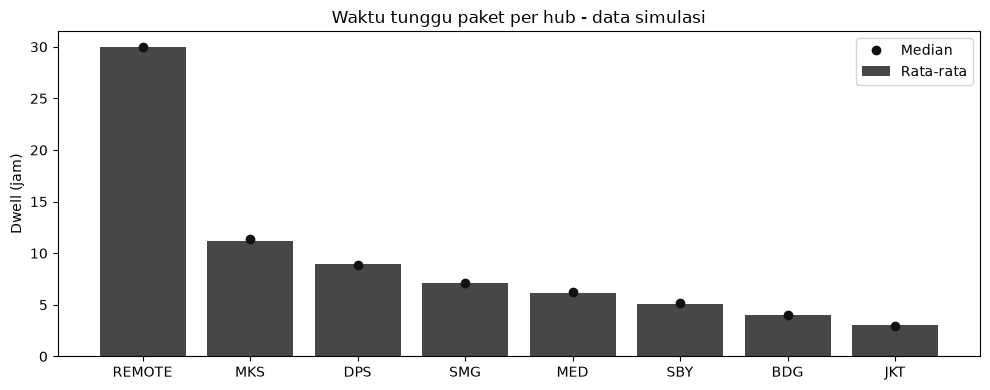

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
chart = hubs.select("hub_id", "avg_dwell_hours", "median_dwell_hours").collect()
fig, ax = plt.subplots(figsize=(10, 4))
positions = list(range(len(chart)))
ax.bar(positions, [r.avg_dwell_hours for r in chart], color="#474747", label="Rata-rata")
ax.plot(positions, [r.median_dwell_hours for r in chart], "o", color="#111111", label="Median")
ax.set_xticks(positions, [r.hub_id.replace("HUB_", "") for r in chart])
ax.set_ylabel("Dwell (jam)")
ax.set_title("Waktu tunggu paket per hub - data simulasi")
ax.legend()
fig.tight_layout()
fig.savefig(output / "dwell_per_hub.png", dpi=160)
plt.show()

## Keterbatasan dan penggunaan pada skala besar

Sampel simulasi September 2026 bukan seluruh populasi pengiriman. Missing scan
bisa membuat rata-rata pasangan lengkap lebih rendah/tinggi daripada kenyataan.
Untuk produksi, sertakan visit_id, event_id, scanner_id dan waktu ingest; tetapkan
watermark untuk late events dan aturan pairing kunjungan berulang. Simpan hasil
besar ke Parquet terpartisi, bukan CSV tunggal di driver, dan ukur shuffle/spill
sebelum tuning. Jangan menyimpulkan kapasitas sorting bermasalah tanpa data shift.

Referensi: [Apache Spark installation](https://spark.apache.org/docs/4.0.1/api/python/getting_started/install.html),
[Spark SQL functions](https://spark.apache.org/docs/4.0.1/api/python/reference/pyspark.sql/functions.html).

In [6]:
groups.unpersist()
spark.stop()
print("Spark session stopped cleanly.")

Spark session stopped cleanly.
